In [2]:
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests


In [3]:
def run_posthoc_analysis(df_diff, label_name):
    """
    Führt deskriptive Statistiken, gepaarte t-Tests und Cohen's d 
    für jeden Block (pair) in einem gepivotteten DataFrame aus.
    """
    stats_list = []

    required_cols = ['pair', 'delay', 'no_delay', 'diff']
    if not all(col in df_diff.columns for col in required_cols):
        print(f"Fehler: DataFrame für {label_name} enthält nicht alle benötigten Spalten.")
        return None

    for p in sorted(df_diff['pair'].unique()):
        pair_data = df_diff[df_diff['pair'] == p].dropna()
        
        m_no_delay = pair_data['no_delay'].mean()
        sd_no_delay = pair_data['no_delay'].std()
        m_delay = pair_data['delay'].mean()
        sd_delay = pair_data['delay'].std()
        
        t_stat, p_unc = stats.ttest_rel(pair_data['delay'], pair_data['no_delay'])
        
        d = pair_data['diff'].mean() / pair_data['diff'].std()
        
        stats_list.append({
            "Block": p,
            "M_No_Delay": m_no_delay, "SD_No_Delay": sd_no_delay,
            "M_Delay": m_delay, "SD_Delay": sd_delay,
            "Diff": m_delay - m_no_delay,
            "t": t_stat,
            "p_unc": p_unc,
            "d": d
        })

    df_results = pd.DataFrame(stats_list)
    
    _, p_adj, _, _ = multipletests(df_results['p_unc'], method='fdr_bh')
    df_results['p_adj'] = p_adj

    print(f"\nPost-hoc Ergebnisse für {label_name}:")
    cols_to_print = ['Block', 'M_No_Delay', 'SD_No_Delay', 'M_Delay', 'SD_Delay', 'Diff', 't', 'p_adj', 'd']
    print(df_results[cols_to_print].round(3).to_string(index=False))
    
    return df_results

## Datenimport und Konsolidierung
Einlesen sämtlicher CSV-Dateien aus dem Verzeichnis `trialDataMainStudy` via `glob` und Zusammenführung in einen DataFrame `df` für die statistische Auswertung.

In [4]:
import glob
import pandas as pd
import os

exclude_ids = ['4089_trialData', '4911_trialData', '5788_trialData', '1324_trialData', '2477_trialData']

files = glob.glob("trialDataMainStudy/*.csv")

filtered_files = [
    f for f in files 
    if not any(ex_id in os.path.basename(f) for ex_id in exclude_ids)
]

df = pd.concat(
    [pd.read_csv(f, sep=",") for f in filtered_files],
    ignore_index=True
)

print(f"Dateien geladen: {len(filtered_files)} (ausgeschlossen: {len(files) - len(filtered_files)})")

Dateien geladen: 38 (ausgeschlossen: 0)


In [5]:
df.head()


,id,gameType,round,trial,timestamp,time,mouseX,mouseY,position,effectDelay,startRT,endRT,RT,status,middleOrbExitCount;
0,1062,rld,0,1,14:07:42.371,639.4381,-2.563947,0.022230,left,0.0,638.7759,639.4381,0.662170,1,0;
1,1062,rld,0,2,14:07:44.188,641.2551,2.691165,0.048921,right,0.6,640.6176,641.2551,0.637451,1,0;
2,1062,rld,0,3,14:07:47.205,644.2722,-1.731190,0.028601,left,0.0,643.8556,644.2722,0.416626,0,1;
3,1062,rld,0,4,14:07:50.702,647.7686,-2.542882,0.100716,left,0.0,646.8018,647.7686,0.966736,1,2;
4,1062,rld,0,5,14:07:53.122,650.1898,2.527869,0.118092,right,0.6,649.5316,650.1898,0.658142,1,0;


In [6]:
df.columns

Index(['id', ' gameType', ' round', ' trial', ' timestamp', ' time', ' mouseX',
       ' mouseY', ' position', ' effectDelay', ' startRT', ' endRT', ' RT',
       ' status', ' middleOrbExitCount;'],
      dtype='str')

### Vorbereitung und Bereinigung der Daten
- Block-Bildung: Die 8 Runden wurden in 4 Blöcke (1-2, 3-4, 5-6, 7-8) zusammengefasst
- Nur erfolgreiche Versuche: Es wurden nur Trials gewertet, bei denen die Kugel korrekt getroffen wurde (status == 1)
- Erster Trial ausgeschlossen: Der jeweils erste Trial einer Runde wurde entfernt (trial != 1), da Probanden hier oft noch nicht bereit sind oder die Runde gerade erst startet
- Ausreißer-Korrektur: Reaktionszeiten über 4 Sekunden (4000 ms) wurden gelöscht, da dies eher auf Ablenkung als auf den experimentellen Effekt hindeutet

In [7]:
def round_to_block(r):
    if r in [1, 2]:
        return "1-2"
    elif r in [3, 4]:
        return "3-4"
    elif r in [5, 6]:
        return "5-6"
    elif r in [7, 8]:
        return "7-8"

df["Block"] = df[" round"].apply(round_to_block)

In [8]:
df = df[df[" round"] != 0]
print(df.head())
df["delay"] = df[" effectDelay"] == 0.6
df = df[df[" trial"] != 1]
df.loc[df[" RT"] >= 4, " status"] = 0


      id  gameType   round   trial      timestamp      time    mouseX  \
10  1062       rld       1       1   14:08:55.957  713.0242  2.393090   
11  1062       rld       1       2   14:08:58.445  715.5121 -2.528859   
12  1062       rld       1       3   14:09:00.349  717.4165 -2.482831   
13  1062       rld       1       4   14:09:02.233  719.3001 -2.518844   
14  1062       rld       1       5   14:09:04.021  721.0879  2.446890   

      mouseY  position   effectDelay   startRT     endRT        RT   status  \
10  0.108663     right           0.6  712.4286  713.0242  0.595581        1   
11 -0.004050      left           0.0  715.0416  715.5121  0.470520        1   
12  0.021978      left           0.0  716.8792  717.4165  0.537292        1   
13 -0.004075      left           0.0  718.8129  719.3001  0.487183        1   
14  0.108940     right           0.6  720.5799  721.0879  0.507996        1   

    middleOrbExitCount; Block  
10                   0;   1-2  
11                   0

In [9]:
def handle_outliers(group):
    clean_hits = group[(group[" status"] == 1) & (group[" RT"] < 4)][" RT"]
    m = clean_hits.mean()
    sd = clean_hits.std()
    
    outlier_condition = (group[" status"] == 1) & ((group[" RT"] > (m + 3*sd)) | (group[" RT"] < (m - 3*sd)))
    group.loc[outlier_condition, " status"] = 0
    return group

In [10]:
df

,id,gameType,round,trial,timestamp,time,mouseX,mouseY,position,effectDelay,startRT,endRT,RT,status,middleOrbExitCount;,Block,delay
11,1062,rld,1,2,14:08:58.445,715.5121,-2.528859,-0.004050,left,0.0,715.0416,715.5121,0.470520,1,0;,1-2,False
12,1062,rld,1,3,14:09:00.349,717.4165,-2.482831,0.021978,left,0.0,716.8792,717.4165,0.537292,1,0;,1-2,False
13,1062,rld,1,4,14:09:02.233,719.3001,-2.518844,-0.004075,left,0.0,718.8129,719.3001,0.487183,1,0;,1-2,False
14,1062,rld,1,5,14:09:04.021,721.0879,2.446890,0.108940,right,0.6,720.5799,721.0879,0.507996,1,0;,1-2,True
15,1062,rld,1,6,14:09:08.892,725.9595,-3.287091,0.006957,left,0.0,725.2138,725.9595,0.745667,0,1;,1-2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18615,9993,lld,8,56,17:19:32.329,1887.8530,2.772861,-0.047360,right,0.0,1887.2280,1887.8530,0.624756,1,1;,7-8,False
18616,9993,lld,8,57,17:19:34.933,1890.4580,2.855240,-0.047238,right,0.0,1889.7620,1890.4580,0.695801,1,1;,7-8,False
18617,9993,lld,8,58,17:19:36.600,1892.1240,2.663580,-0.082634,right,0.0,1891.4370,1892.1240,0.687256,1,0;,7-8,False
18618,9993,lld,8,59,17:19:37.992,1893.5160,2.836896,-0.108827,right,0.0,1893.0080,1893.5160,0.508057,1,0;,7-8,False


In [11]:
id_backup = df["id"]
effect_delay_backup = df[" effectDelay"]

In [12]:
df = df.groupby(["id", " effectDelay"], group_keys=False).apply(handle_outliers)

In [13]:
df["id"] = id_backup
df["effectDelay"] = effect_delay_backup

In [14]:
len(df)

17936

In [15]:
df_er = df.groupby(["id", "Block", "delay"])[" status"].apply(
    lambda x: (x == 0).mean() * 100
).reset_index(name="ER")

print(df_er.groupby(["Block", "delay"])["ER"].mean())

Block  delay
1-2    False     8.127621
       True      6.938258
3-4    False     9.112964
       True      6.376029
5-6    False    11.664360
       True      7.676977
7-8    False    10.445184
       True      7.637577
Name: ER, dtype: float64


In [16]:
df_er.head()

,id,Block,delay,ER
0,1062,1-2,False,10.000000
1,1062,1-2,True,10.344828
2,1062,3-4,False,23.728814
3,1062,3-4,True,11.864407
4,1062,5-6,False,6.666667


In [17]:
df_er_diff = df_er.pivot(index=["id", "Block"], columns="delay", values="ER").reset_index()
df_er_diff["ER_diff"] = df_er_diff[True] - df_er_diff[False]

print(df_er_diff.head())

delay    id Block      False       True    ER_diff
0      1062   1-2  10.000000  10.344828   0.344828
1      1062   3-4  23.728814  11.864407 -11.864407
2      1062   5-6   6.666667  10.344828   3.678161
3      1062   7-8  23.728814  23.728814   0.000000
4      1099   1-2   0.000000   0.000000   0.000000


In [18]:
desc_delay = df_er.groupby("delay")["ER"].agg(["mean", "std"])
print("--- Werte für den Haupteffekt Delay ER ---")
print(desc_delay)

df_pivot = df_er.pivot(index=["id", "Block"], columns="delay", values="ER").reset_index()

cols = sorted([c for c in df_pivot.columns if c not in ["id", "Block"]])
no_delay_col = cols[0] 
delay_col = cols[1]

results = []

for block in sorted(df_pivot["Block"].unique()):
    block_data = df_pivot[df_pivot["Block"] == block].dropna(subset=[no_delay_col, delay_col])
    
    nd = block_data[no_delay_col]
    d_val = block_data[delay_col]
    
    m_nd, sd_nd = nd.mean(), nd.std()
    m_d, sd_d = d_val.mean(), d_val.std()
    
    diff = m_d - m_nd
    t_stat, p_val = stats.ttest_rel(d_val, nd)
    df_val = len(block_data) - 1
    
    diff_scores = d_val - nd
    cohen_d = diff_scores.mean() / diff_scores.std() if diff_scores.std() != 0 else 0
    
    results.append({
        "Block": block,
        "M No Delay": m_nd, "SD No Delay": sd_nd,
        "M Delay": m_d, "SD Delay": sd_d,
        "Diff": diff, "t": t_stat, "df": df_val, "p_unc": p_val, "d": cohen_d
    })

df_table = pd.DataFrame(results)

_, p_adj, _, _ = multipletests(df_table['p_unc'], method='fdr_bh')
df_table['p_adj'] = p_adj

print("Error Rate (ER, in %)")
print(df_table.round(3).to_markdown(index=False))

--- Werte für den Haupteffekt Delay ER ---
           mean        std
delay                     
False  9.837532  11.155375
True   7.157210   7.892477
Error Rate (ER, in %)
| Block   |   M No Delay |   SD No Delay |   M Delay |   SD Delay |   Diff |      t |   df |   p_unc |      d |   p_adj |
|:--------|-------------:|--------------:|----------:|-----------:|-------:|-------:|-----:|--------:|-------:|--------:|
| 1-2     |        8.128 |         8.466 |     6.938 |      7.032 | -1.189 | -1.778 |   37 |   0.084 | -0.288 |   0.084 |
| 3-4     |        9.113 |        11.029 |     6.376 |      7.168 | -2.737 | -2.442 |   37 |   0.02  | -0.396 |   0.039 |
| 5-6     |       11.664 |        12.765 |     7.677 |      8.051 | -3.987 | -3.107 |   37 |   0.004 | -0.504 |   0.014 |
| 7-8     |       10.445 |        12.011 |     7.638 |      9.349 | -2.808 | -2.196 |   37 |   0.034 | -0.356 |   0.046 |


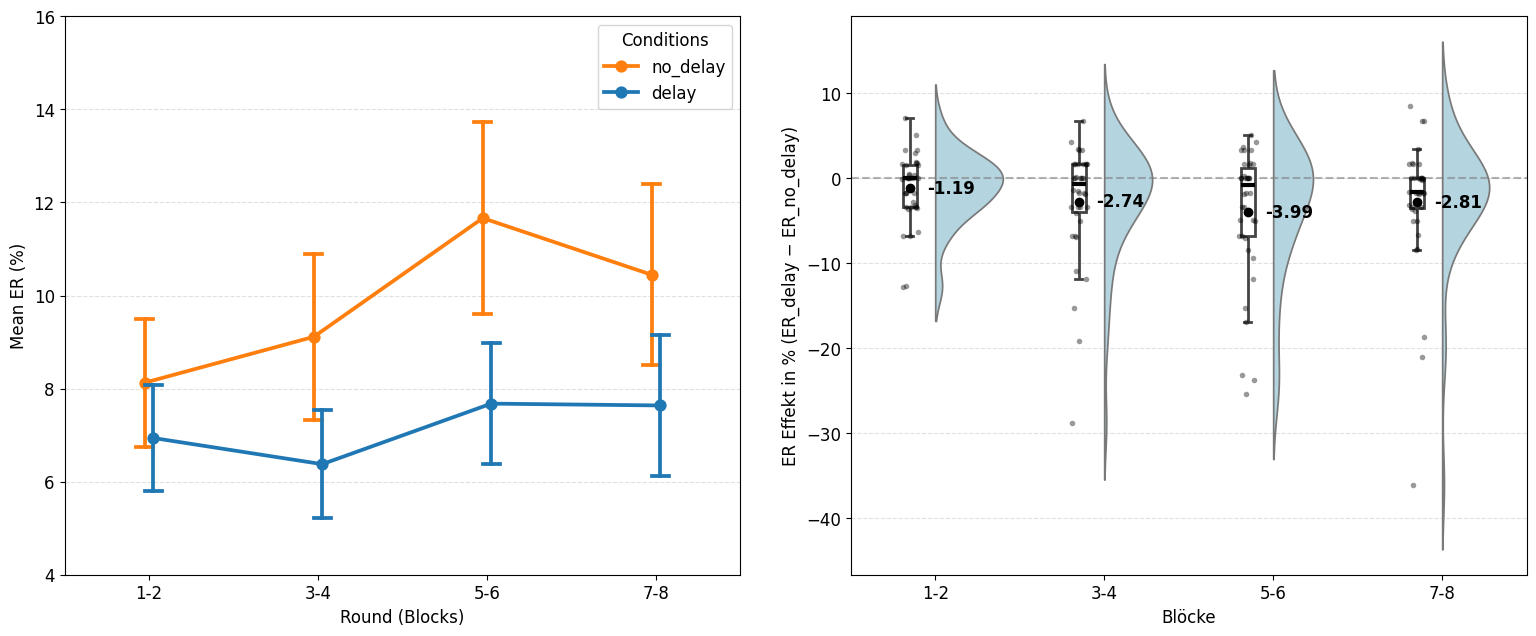

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import PathPatch

base_size = 12  
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

sns.pointplot(
    data=df_er, 
    x="Block", 
    y="ER", 
    hue="delay", 
    palette=["#ff7f0e", "#1f77b4"],
    errorbar="se", 
    dodge=True,
    markers=["o", "o"],
    capsize=.1,
    ax=ax[0]
)

ax[0].set_axisbelow(True)
ax[0].grid(axis='y', linestyle='--', alpha=0.7, color='lightgrey')
ax[0].set_ylabel("Mean ER (%)", fontsize=base_size)
ax[0].set_xlabel("Round (Blocks)", fontsize=base_size)
ax[0].set_ylim(4, 16)
ax[0].tick_params(labelsize=base_size)
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(
    handles=handles, 
    labels=["no_delay", "delay"], 
    title="Conditions", 
    fontsize=base_size, 
    title_fontsize=base_size
)


sns.violinplot(
    data=df_er_diff, x="Block", y="ER_diff", 
    inner=None, color="lightblue", alpha=1, ax=ax[1]
)

for art in ax[1].findobj(PolyCollection):
    for path in art.get_paths():
        center = np.mean(path.vertices[:, 0])
        path.vertices[:, 0] = np.maximum(path.vertices[:, 0], center)

sns.boxplot(
    data=df_er_diff, x="Block", y="ER_diff", 
    width=0.08, color="white", linewidth=2, showfliers=False, 
    showmeans=True,
    boxprops={'edgecolor': '#444444', 'facecolor': 'white'},
    whiskerprops={'color': '#444444'},
    capprops={'color': '#444444'},
    meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":"6"},
    medianprops={'color': 'black', 'linewidth': 3},
    ax=ax[1], zorder=10
)

sns.stripplot(
    data=df_er_diff, x="Block", y="ER_diff", 
    color="black", alpha=0.4, size=4, jitter=0.05, ax=ax[1], zorder=20
)


offset = -0.15 
for artist in ax[1].collections:
    if not isinstance(artist, PolyCollection):
        offsets = artist.get_offsets()
        offsets[:, 0] = offsets[:, 0] + offset
        artist.set_offsets(offsets)

for patch in ax[1].patches:
    if isinstance(patch, PathPatch):
        path = patch.get_path()
        for i in range(len(path.vertices)):
            path.vertices[i, 0] += offset

for line in ax[1].lines:
    if line.get_linestyle() != "--":
        line.set_xdata(line.get_xdata() + offset)

means = df_er_diff.groupby("Block")["ER_diff"].mean()
for i, block in enumerate(df_er_diff["Block"].unique()):
    val = means[block]
    ax[1].text(i + offset + 0.1, val, f"{val:.2f}", 
               verticalalignment='center', fontsize=base_size, fontweight='bold', color='black')

ax[1].set_axisbelow(True)
ax[1].grid(axis='y', linestyle='--', alpha=0.7, color='lightgrey')
ax[1].axhline(0, linestyle="--", color="grey", alpha=0.6, linewidth=1.5)
ax[1].set_ylabel("ER Effekt in % (ER_delay − ER_no_delay)", fontsize=base_size)
ax[1].set_xlabel("Blöcke", fontsize=base_size)
ax[1].tick_params(labelsize=base_size)

plt.subplots_adjust(wspace=0.3) 
plt.tight_layout(pad=3.0) 

plt.show()

In [20]:
aov_er = pg.rm_anova(
    dv="ER", 
    within=["delay", "Block"], 
    subject="id", 
    data=df_er
)

print("ANOVA Ergebnisse für Error Rate:")
print(aov_er)

ANOVA Ergebnisse für Error Rate:
          Source          SS  ddof1  ddof2          MS          F     p_unc  \
0          delay  545.993521      1     37  545.993521  10.640475  0.002382   
1          Block  240.883593      3    111   80.294531   3.314145  0.022655   
2  delay * Block   75.064702      3    111   25.021567   1.728885  0.165198   

   p_GG_corr       ng2       eps  
0   0.002382  0.019207  1.000000  
1   0.026367  0.008566  0.917059  
2   0.173089  0.002685  0.865384  


In [21]:
df = df[df[" status"] == 1]
df = df[df[" RT"] < 4]


In [22]:
len(df)

16411

Erstellung einer Spalte `delay`, die kennzeichnet, ob in einem Trial die spezifische Verzögerung von 0,6 Sekunden (`effectDelay`) vorlag.

In [23]:
df["delay"] = df["effectDelay"] == 0.6


In [24]:
df_delay = df[df["delay"] == True]
df_no_delay = df[df["delay"] == False]



## Aggregation der Reaktionszeiten
Berechnung der mittleren Reaktionszeit (`meanRT`) pro Proband (`id`), Versuchsblock (`Block`) und Bedingung (`delay`).

In [25]:
df_agg = (
    df
    .groupby(["id", "Block", "delay"], as_index=False)
    .agg(meanRT=(" RT", "mean"))
)


In [26]:
df_agg.head()

,id,Block,delay,meanRT
0,1062,1-2,False,0.517867
1,1062,1-2,True,0.543090
2,1062,3-4,False,0.494444
3,1062,3-4,True,0.539969
4,1062,5-6,False,0.587396


In [27]:
df_agg.head()
df_agg.groupby(["Block", "delay"]).size()


Block  delay
1-2    False    38
       True     38
3-4    False    38
       True     38
5-6    False    38
       True     38
7-8    False    38
       True     38
dtype: int64

## Berechnung der Block-Mittelwerte
Ermittlung der durchschnittlichen Reaktionszeiten pro Versuchsblock und Bedingung (`delay`).

In [28]:
df_agg["meanRT"] = df_agg["meanRT"]*1000


In [29]:
mean_by_block_delay = df_agg.groupby(["Block", "delay"])["meanRT"].mean().reset_index()

print(mean_by_block_delay)

  Block  delay      meanRT
0   1-2  False  623.419136
1   1-2   True  637.053924
2   3-4  False  564.538160
3   3-4   True  583.491155
4   5-6  False  533.298858
5   5-6   True  560.112112
6   7-8  False  519.252532
7   7-8   True  553.388602


In [30]:
df_pivot = df_agg.pivot(index=['id', 'Block'], columns='delay', values='meanRT').reset_index()
df_pivot.columns = ['id', 'Block', 'No_Delay', 'Delay']

stats_list = []

for block in sorted(df_pivot['Block'].unique()):
    block_data = df_pivot[df_pivot['Block'] == block].dropna()
    
    m_nd, sd_nd = block_data['No_Delay'].mean(), block_data['No_Delay'].std()
    m_d, sd_d = block_data['Delay'].mean(), block_data['Delay'].std()
    
    t_stat, p_unc = stats.ttest_rel(block_data['Delay'], block_data['No_Delay'])
    
    diff_scores = block_data['Delay'] - block_data['No_Delay']
    d = diff_scores.mean() / diff_scores.std()
    
    stats_list.append({
        "Block": block,
        "M_No_Delay": m_nd, "SD_No_Delay": sd_nd,
        "M_Delay": m_d, "SD_Delay": sd_d,
        "Diff": m_d - m_nd,
        "t": t_stat,
        "p_unc": p_unc,
        "d": d
    })

df_results = pd.DataFrame(stats_list)
_, p_adj, _, _ = multipletests(df_results['p_unc'], method='fdr_bh')
df_results['p'] = p_adj

# Ausgabe der Tabelle
print(df_results[['Block', 'M_No_Delay', 'SD_No_Delay', 'M_Delay', 'SD_Delay', 'Diff', 't', 'p', 'd']].round(2))

  Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t     p     d
0   1-2      623.42       106.87   637.05    104.61  13.63  2.56  0.01  0.41
1   3-4      564.54       102.47   583.49     99.99  18.95  3.91  0.00  0.63
2   5-6      533.30       106.75   560.11    106.95  26.81  5.04  0.00  0.82
3   7-8      519.25       115.84   553.39    115.75  34.14  6.10  0.00  0.99


## Verlaufsgrafik der Reaktionszeiten
Erstellung eines Pointplots, um die Veränderung der mittleren Reaktionszeit über die Blöcke hinweg darzustellen.

## Differenz der Reaktionszeiten berechnen
Die Daten werden so umgeformt (Pivot), dass die Werte mit und ohne Delay direkt nebeneinander in einer Zeile stehen. Dann wird die Differenz (`RT_diff`) zwischen beiden Bedingungen berechnet, um den Effekt der Verzögerung pro Proband und Block zu isolieren.

In [31]:
df_diff = (
    df_agg
    .pivot(index=["id", "Block"], columns="delay", values="meanRT")
    .reset_index()
)

df_diff["RT_diff"] = df_diff[True] - df_diff[False]


## Visualisierung des Delay-Effekts
Hier wird der Unterschied zwischen den Bedingungen (Delay minus kein Delay) über die Blöcke hinweg dargestellt.

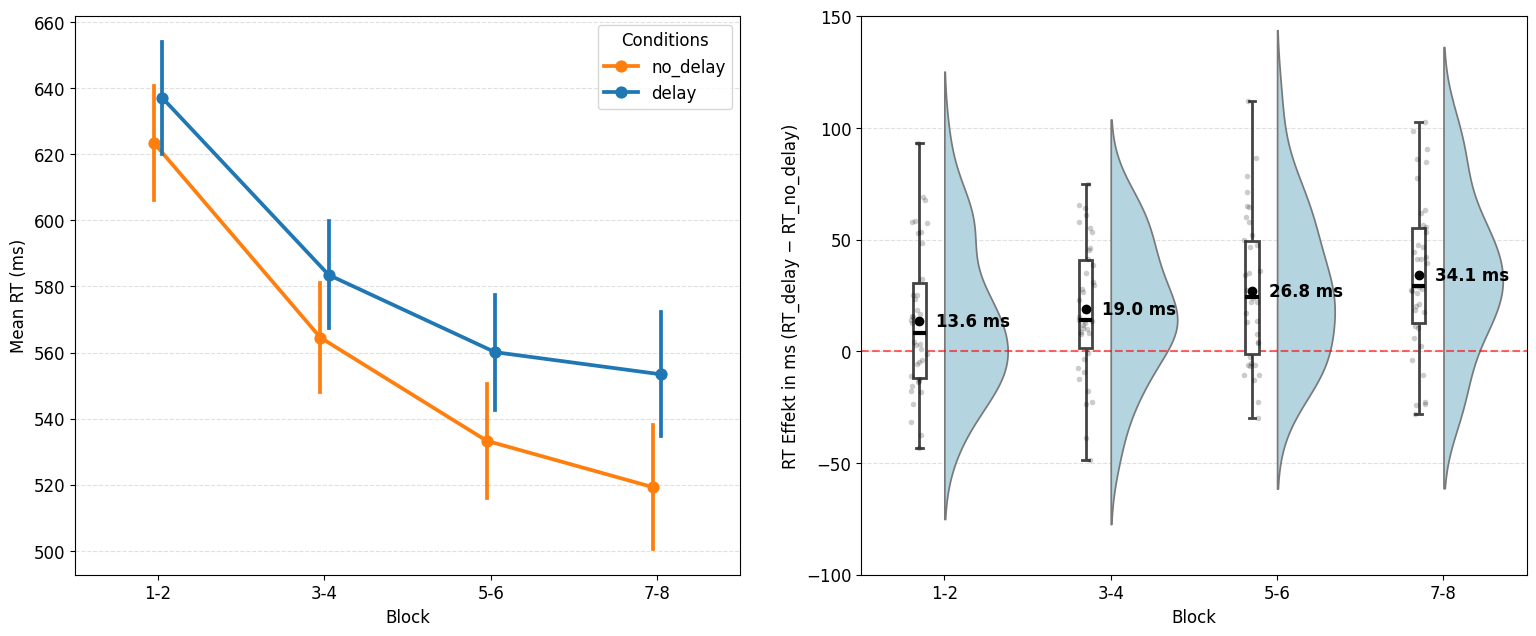

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import PathPatch

base_size = 12 
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

sns.pointplot(
    data=df_agg,
    x="Block",
    y="meanRT",
    palette=["#ff7f0e", "#1f77b4"],
    hue="delay",
    errorbar="se",
    dodge=True,
    ax=ax[0]
)

ax[0].set_axisbelow(True)
ax[0].grid(axis='y', linestyle='--', alpha=0.7, color='lightgrey')
ax[0].set_ylabel("Mean RT (ms)", fontsize=base_size) 
ax[0].set_xlabel("Block", fontsize=base_size)
ax[0].tick_params(labelsize=base_size)
ax[0].legend(
    handles=handles, 
    labels=["no_delay", "delay"], 
    title="Conditions", 
    fontsize=base_size, 
    title_fontsize=base_size
)


plot_df = df_diff.copy()
target_col = "RT_diff"

sns.violinplot(
    data=plot_df, x="Block", y=target_col, 
    inner=None, color="lightblue", alpha=1, ax=ax[1]
)

for art in ax[1].findobj(PolyCollection):
    for path in art.get_paths():
        center = np.mean(path.vertices[:, 0])
        path.vertices[:, 0] = np.maximum(path.vertices[:, 0], center)

sns.boxplot(
    data=plot_df, x="Block", y=target_col, 
    width=0.08, color="white", linewidth=2, showfliers=False, 
    showmeans=True,
    boxprops={'edgecolor': '#444444', 'facecolor': 'white'},
    whiskerprops={'color': '#444444'},
    capprops={'color': '#444444'},
    meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":"6"},
    medianprops={'color': 'black', 'linewidth': 3},
    ax=ax[1], zorder=10
)

sns.stripplot(
    data=plot_df, x="Block", y=target_col, 
    color="black", alpha=0.2, size=4, jitter=0.05, ax=ax[1], zorder=20
)

offset = -0.15 
for artist in ax[1].collections:
    if not isinstance(artist, PolyCollection):
        offsets = artist.get_offsets()
        offsets[:, 0] = offsets[:, 0] + offset
        artist.set_offsets(offsets)

for patch in ax[1].patches:
    if isinstance(patch, PathPatch):
        path = patch.get_path()
        for i in range(len(path.vertices)):
            path.vertices[i, 0] += offset

for line in ax[1].lines:
    if line.get_linestyle() != "--":
        line.set_xdata(line.get_xdata() + offset)

means = plot_df.groupby("Block")[target_col].mean()
for i, block in enumerate(sorted(plot_df["Block"].unique())):
    val = means[block]
    ax[1].text(i + offset + 0.1, val, f"{val:.1f} ms", 
               verticalalignment='center', fontsize=base_size, fontweight='bold', color='black')

ax[1].axhline(0, linestyle="--", color="red", alpha=0.6, linewidth=1.5)
ax[1].set_axisbelow(True)
ax[1].grid(axis='y', linestyle='--', alpha=0.7, color='lightgrey')
ax[1].set_ylim(-100, 150)
ax[1].set_ylabel("RT Effekt in ms (RT_delay − RT_no_delay)", fontsize=base_size)
ax[1].set_xlabel("Block", fontsize=base_size)
ax[1].tick_params(labelsize=base_size)

plt.subplots_adjust(wspace=0.3) 

plt.tight_layout(pad=3.0) 

plt.show()

## Datentypen anpassen
Hier werden die Spalten `Block` und `delay` in Kategorien umgewandelt. Das ist wichtig, damit sie bei der späteren statistischen Analyse (z. B. ANOVA) korrekt als Gruppen behandelt werden.

In [33]:
df_agg["Block"] = df_agg["Block"].astype("category")
df_agg["delay"] = df_agg["delay"].astype("category")


## Messwiederholungs-ANOVA (rmANOVA)
Statistische Überprüfung der Haupteffekte und Interaktionen:
- **Haupteffekt Delay:** Hat die Verzögerung einen generellen Einfluss auf die Reaktionszeit?
- **Haupteffekt Block:** Verändern sich die Zeiten über die vier Blöcke (z. B. Lerneffekt)?
- **Interaktion (Block * Delay):** Verändert sich der Effekt der Verzögerung im Laufe des Experiments?

In [34]:
import pingouin as pg

aov = pg.rm_anova(
    dv="meanRT",
    within=["Block", "delay"],
    subject="id",
    data=df_agg,
    detailed=True,
    effsize="np2"
)

print(aov)


          Source             SS  ddof1  ddof2             MS          F  \
0          Block  403427.462554      3    111  134475.820851  36.750780   
1          delay   41558.654602      1     37   41558.654602  27.152134   
2  Block * delay    4598.906831      3    111    1532.968944   7.792948   

          p_unc     p_GG_corr       np2       eps  
0  1.426384e-16  8.395284e-13  0.498310  0.735965  
1  7.342576e-06  7.342576e-06  0.423246  1.000000  
2  9.079254e-05  3.136220e-04  0.173977  0.814488  


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import PathPatch

def plot_results(stat_df, diff_df, y_col, ylabel_left, ylabel_right, pair_order=None, base_size=12, decimals = 1):
    """
    Erstellt einen kombinierten Plot: 
    Links Interaction-Plot (Pointplot), rechts Raincloud-Plot (Differenz).
    """
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))
    
    sns.pointplot(
        data=stat_df,
        x="pair",
        y=y_col,
        hue="condition",
        errorbar="se",
        order=pair_order,
        dodge=True,
        ax=ax[0]
    )

    ax[0].set_ylabel(ylabel_left, fontsize=base_size)
    ax[0].set_xlabel("Block", fontsize=base_size)
    ax[0].grid(axis='y', linestyle='--', alpha=0.7)
    ax[0].legend(title="Condition")

    target_col = "diff"
    x_col = "pair"
    
    sns.violinplot(
        data=diff_df, x=x_col, y=target_col, 
        inner=None, color="lightblue", alpha=1, ax=ax[1], order=pair_order
    )

    for art in ax[1].findobj(PolyCollection):
        for path in art.get_paths():
            center = np.mean(path.vertices[:, 0])
            path.vertices[:, 0] = np.maximum(path.vertices[:, 0], center)

    sns.boxplot(
        data=diff_df, x=x_col, y=target_col, 
        width=0.06, color="white", linewidth=2, showfliers=False, 
        showmeans=True,
        boxprops={'edgecolor': '#444444', 'facecolor': 'white'},
        whiskerprops={'color': '#444444'},
        capprops={'color': '#444444'},
        meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":"6"},
        medianprops={'color': 'black', 'linewidth': 3},
        ax=ax[1], zorder=10, order=pair_order
    )

    sns.stripplot(
        data=diff_df, x=x_col, y=target_col, 
        color="black", alpha=0.2, size=4, jitter=0.05, ax=ax[1], zorder=20, order=pair_order
    )

    offset = -0.15 
    for artist in ax[1].collections:
        if not isinstance(artist, PolyCollection):
            offsets = artist.get_offsets()
            offsets[:, 0] = offsets[:, 0] + offset
            artist.set_offsets(offsets)

    for patch in ax[1].patches:
        if isinstance(patch, PathPatch):
            path = patch.get_path()
            for i in range(len(path.vertices)):
                path.vertices[i, 0] += offset

    for line in ax[1].lines:
        if line.get_linestyle() != "--":
            line.set_xdata(line.get_xdata() + offset)

    means = diff_df.groupby(x_col)[target_col].mean()
    current_order = pair_order if pair_order is not None else sorted(diff_df[x_col].unique())
    
    for i, block in enumerate(current_order):
        if block in means:
            val = means[block]
            ax[1].text(i + offset + 0.1, val, f"{val:.{decimals}f}", 
                       verticalalignment='center', fontsize=10, fontweight='bold', color='black')

    ax[1].axhline(0, linestyle="--", color="red", alpha=0.6, linewidth=1.5)
    ax[1].set_ylabel(ylabel_right, fontsize=base_size)
    ax[1].set_xlabel("Block", fontsize=base_size)
    ax[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(pad=3.0)
    return fig, ax

## Laden der aggregierten Daten
Import der zuvor erstellten Datei `agg_df.csv`, die die zusammengefassten Kennwerte der Studie enthält.

In [36]:
stat_df = pd.read_csv("agg_df.csv", encoding="utf-8")

print(stat_df.head())

     id condition pair  time_to_ballistic_start  avg_ballistic_speed  \
0  1062     delay  1_2               220.250000            16.381319   
1  1062     delay  3_4               205.788462            16.443773   
2  1062     delay  5_6               207.173077            16.820034   
3  1062     delay  7_8               209.377778            18.597047   
4  1062  no_delay  1_2               216.148148            15.369429   

   overshoots  undershoots  max_ballistic_speed  verification_duration  \
0    0.057692     0.230769            33.610066              76.538462   
1    0.019231     0.211538            31.556219              94.807692   
2    0.115385     0.461538            34.019841             103.269231   
3    0.022222     0.133333            34.026858              58.288889   
4    0.055556     0.092593            30.763832              85.740741   

   correction_duration  ballistic_duration       auc  avg_correction_speed  \
0            65.211538          171.057692  

## Vergleich der ballistichen Geschwindigkeit
Visualisierung der durchschnittlichen ballistichen Geschwindigkeit (`avg_ballistic_speed`) über die verschiedenen Trial-Paare hinweg. Der Vergleich erfolgt getrennt nach Versuchsbedingung (`condition`), um zu sehen, wie sich das Tempo im Verlauf der Blöcke verändert.

In [37]:
df_diff_avg_ballistic_speed = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='avg_ballistic_speed'
).reset_index()
df_diff_avg_ballistic_speed['diff'] = df_diff_avg_ballistic_speed['delay'] - df_diff_avg_ballistic_speed['no_delay']

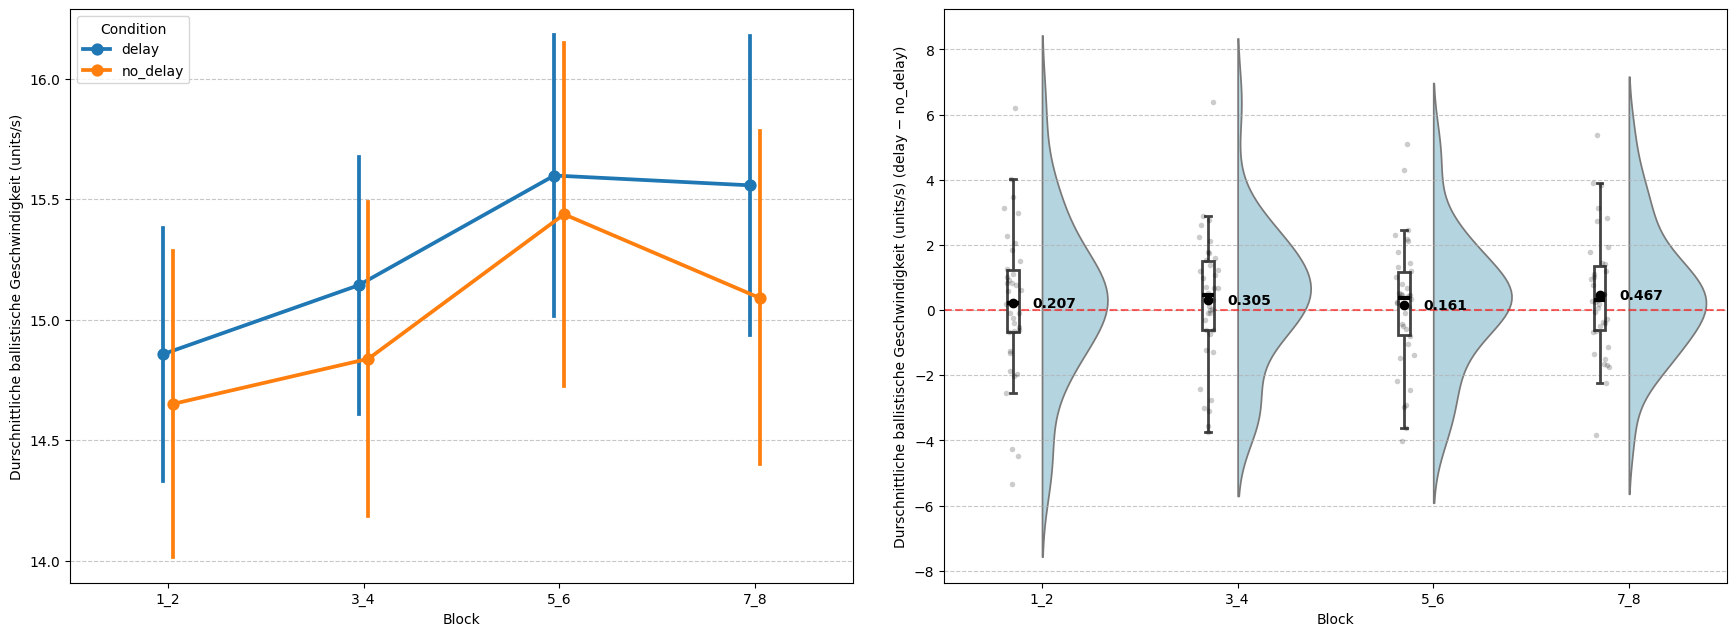

In [38]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_avg_ballistic_speed, 
    y_col="avg_ballistic_speed", 
    ylabel_left="Durschnittliche ballistische Geschwindigkeit (units/s)", 
    ylabel_right="Durschnittliche ballistische Geschwindigkeit (units/s) (delay − no_delay)",
    pair_order=None,
    base_size=10,
    decimals=3
)

## ANOVA: Ballistische Geschwindigkeit
Statistische Überprüfung, ob die Bedingung (Condition) und der zeitliche Verlauf (Pair) die ballistische Geschwindigkeit beeinflussen. Außerdem wird getestet, ob es eine Interaktion gibt – also ob die Bedingung je nach Trial-Paar unterschiedlich wirkt.

In [39]:
aov = pg.rm_anova(
    dv="avg_ballistic_speed",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source         SS  ddof1  ddof2        MS         F     p_unc  \
0         condition   6.171428      1     37  6.171428  0.924420  0.342559   
1              pair  26.463168      3    111  8.821056  3.292398  0.023285   
2  condition * pair   1.048317      3    111  0.349439  0.628576  0.598053   

   p_GG_corr       np2       eps  
0   0.342559  0.024375  1.000000  
1   0.041020  0.081713  0.688345  
2   0.569046  0.016705  0.827809  


## Verlauf der maximalen ballistischen Geschwindigkeit
Visualisierung der Spitzen-Geschwindigkeit (`max_ballistic_speed`) über die verschiedenen Trial-Paare.

In [40]:
df_diff_max_ballistic_speed = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='max_ballistic_speed'
).reset_index()
df_diff_max_ballistic_speed['diff'] = df_diff_max_ballistic_speed['delay'] - df_diff_max_ballistic_speed['no_delay']

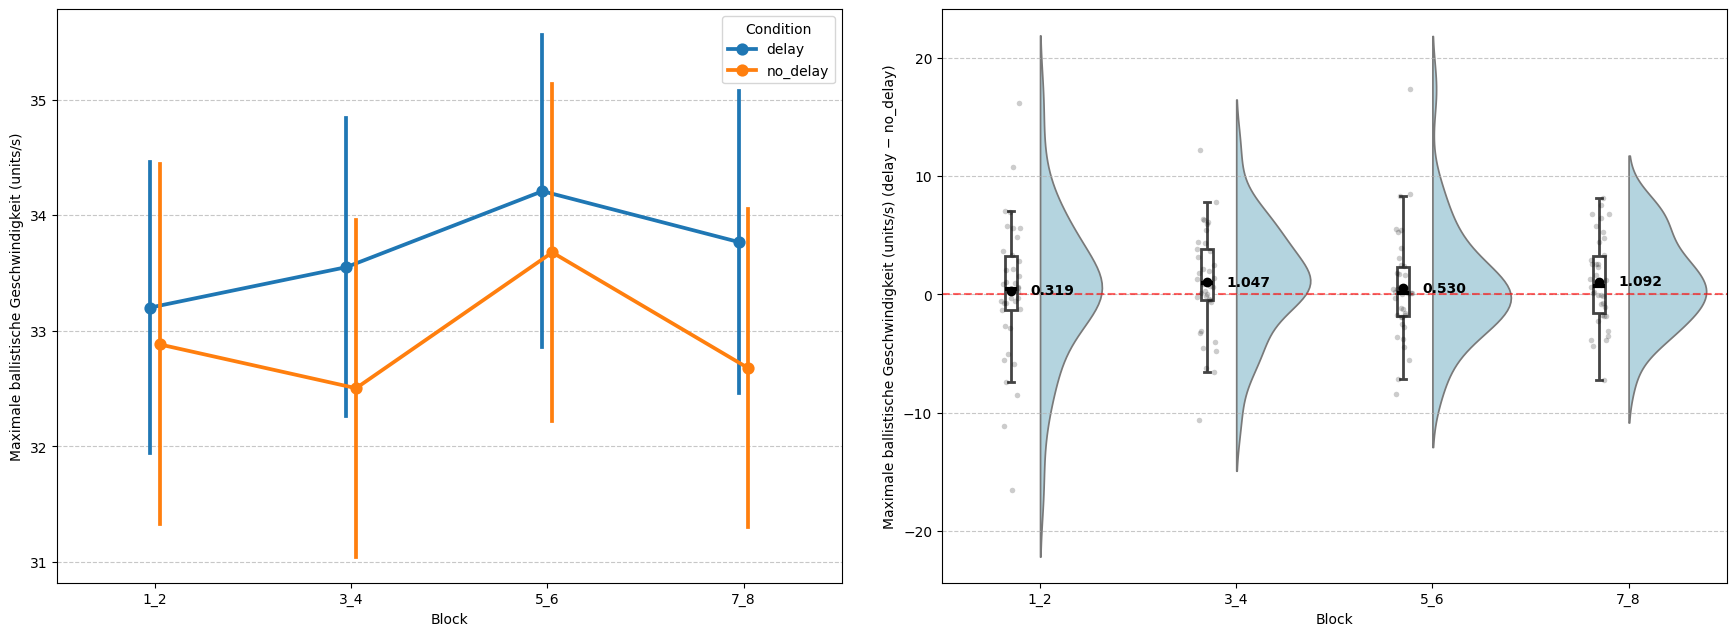

In [41]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_max_ballistic_speed, 
    y_col="max_ballistic_speed", 
    ylabel_left="Maximale ballistische Geschwindigkeit (units/s)", 
    ylabel_right="Maximale ballistische Geschwindigkeit (units/s) (delay − no_delay)",
    pair_order=None,
    base_size=10,
    decimals=3
)

In [42]:
aov = pg.rm_anova(
    dv="max_ballistic_speed",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source         SS  ddof1  ddof2         MS         F     p_unc  \
0         condition  42.402247      1     37  42.402247  1.218193  0.276842   
1              pair  42.608984      3    111  14.202995  1.447341  0.232938   
2  condition * pair   8.353536      3    111   2.784512  0.832245  0.478893   

   p_GG_corr       np2       eps  
0   0.276842  0.031875  1.000000  
1   0.240880  0.037645  0.715367  
2   0.442348  0.021998  0.688765  


## Analyse des Startzeitpunkts der ballistischen Phase
Dieser Plot zeigt die Dauer bis zum Beginn der ballistischen Phase (`time_to_ballistic_start`). Damit untersuchen wir, ob das Delay einen Einfluss darauf hat, wie schnell die Probanden die eigentliche Zielbewegung starten.

In [43]:
aov = pg.rm_anova(
    dv="time_to_ballistic_start",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source           SS  ddof1  ddof2           MS          F  \
0         condition  5068.968293      1     37  5068.968293   7.328087   
1              pair  7853.351774      3    111  2617.783925  19.381549   
2  condition * pair  1607.912820      3    111   535.970940   7.907297   

          p_unc     p_GG_corr       np2       eps  
0  1.021192e-02  1.021192e-02  0.165315  1.000000  
1  3.547298e-10  3.180613e-08  0.343757  0.756998  
2  7.924470e-05  1.657672e-04  0.176080  0.891401  


In [44]:
df_diff_ballistic_start = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='time_to_ballistic_start'
).reset_index()
df_diff_ballistic_start['diff'] = df_diff_ballistic_start['delay'] - df_diff_ballistic_start['no_delay']

In [45]:
df_results_ballistic_start = run_posthoc_analysis(df_diff_ballistic_start, "ballistic_start")


Post-hoc Ergebnisse für ballistic_start:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t  p_adj     d
  1_2     179.337       20.072  181.017    26.040  1.679 0.545  0.589 0.088
  3_4     174.223       26.006  180.249    26.624  6.026 1.559  0.170 0.253
  5_6     165.501       21.429  177.378    23.010 11.877 3.970  0.001 0.644
  7_8     160.518       19.834  173.604    26.662 13.086 3.532  0.002 0.573


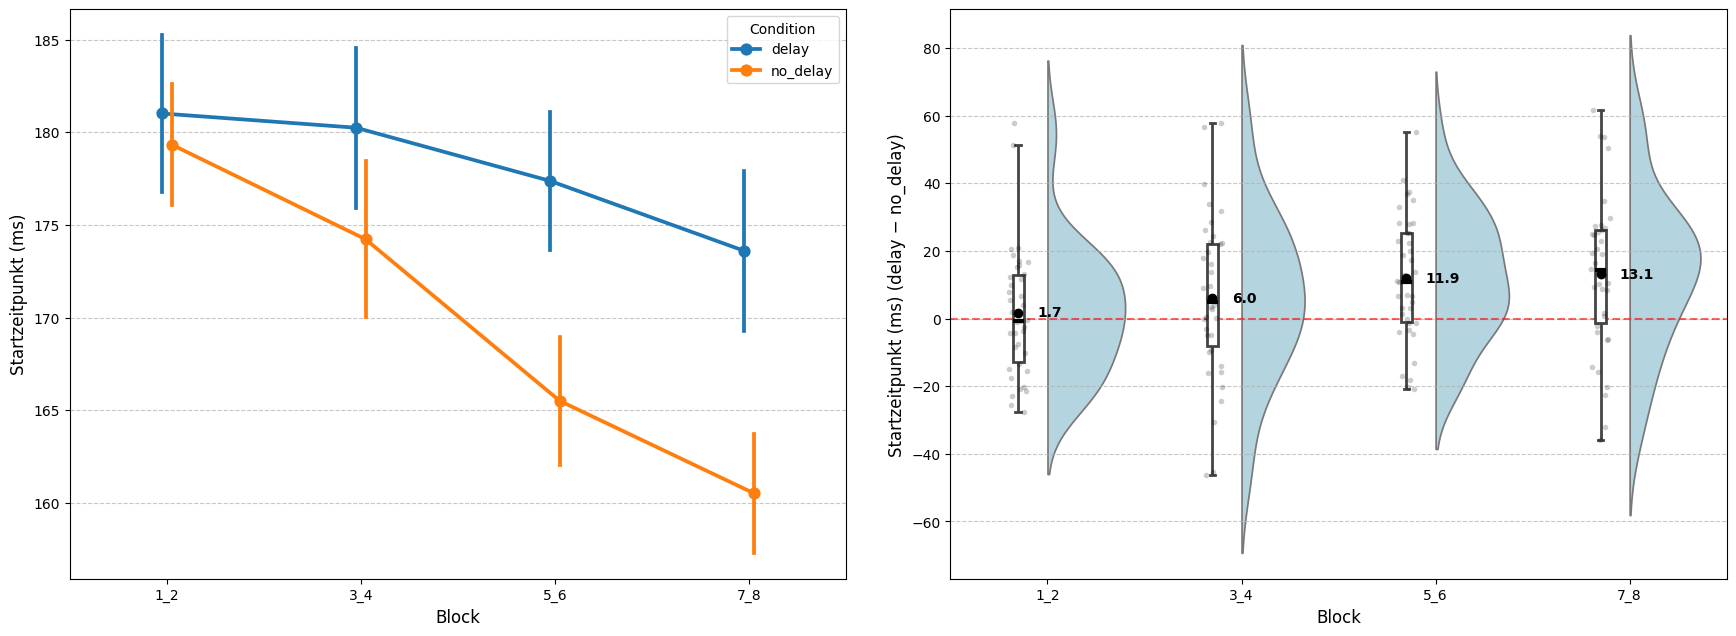

In [46]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_ballistic_start, 
    y_col="time_to_ballistic_start", 
    ylabel_left="Startzeitpunkt (ms)", 
    ylabel_right="Startzeitpunkt (ms) (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=1
)

In [47]:
df_diff_verification_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='verification_duration'
).reset_index()
df_diff_verification_duration['diff'] = df_diff_verification_duration['delay'] - df_diff_verification_duration['no_delay']

In [48]:
df_results_verification_duration = run_posthoc_analysis(df_diff_verification_duration, "verification_duration")


Post-hoc Ergebnisse für verification_duration:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay  Diff     t  p_adj     d
  1_2     111.104       29.830  114.478    32.147 3.374 1.450  0.156 0.235
  3_4     100.357       34.553  106.378    34.991 6.021 2.672  0.022 0.433
  5_6      93.007       35.590   99.065    38.247 6.058 2.312  0.035 0.375
  7_8      89.021       42.491   98.879    43.399 9.857 3.437  0.006 0.558


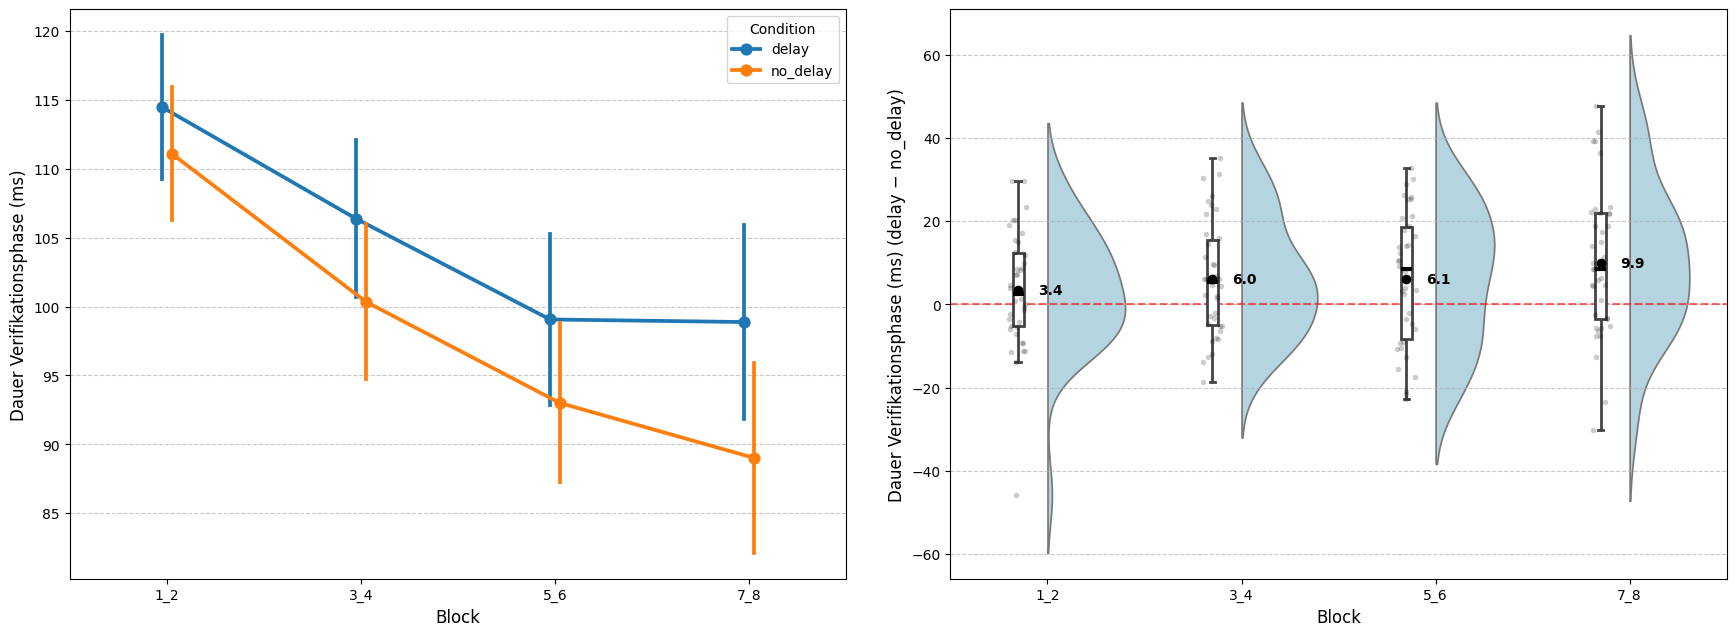

In [49]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_verification_duration, 
    y_col="verification_duration", 
    ylabel_left="Dauer Verifikationsphase (ms)", 
    ylabel_right="Dauer Verifikationsphase (ms) (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=1
)

In [50]:
aov = pg.rm_anova(
    dv="verification_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source            SS  ddof1  ddof2           MS          F  \
0         condition   3042.840753      1     37  3042.840753  11.676357   
1              pair  16555.655959      3    111  5518.551986   9.238094   
2  condition * pair    405.619882      3    111   135.206627   1.798682   

      p_unc  p_GG_corr       np2       eps  
0  0.001553   0.001553  0.239877  1.000000  
1  0.000017   0.000355  0.199794  0.630289  
2  0.151587   0.156033  0.046359  0.928752  


In [51]:
mean_by_block_delay = stat_df.groupby(["pair", "condition"])["verification_duration"].mean().reset_index()

print(mean_by_block_delay)

  pair condition  verification_duration
0  1_2     delay             114.478272
1  1_2  no_delay             111.104229
2  3_4     delay             106.378480
3  3_4  no_delay             100.357199
4  5_6     delay              99.064525
5  5_6  no_delay              93.007019
6  7_8     delay              98.878513
7  7_8  no_delay              89.021305


In [52]:
df_diff_undershoots = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='undershoots'
).reset_index()
df_diff_undershoots['diff'] = df_diff_undershoots['delay'] - df_diff_undershoots['no_delay']

In [53]:
df_diff_overshoots = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='overshoots'
).reset_index()
df_diff_overshoots['diff'] = df_diff_overshoots['delay'] - df_diff_overshoots['no_delay']

In [54]:
df_diff_auc = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='auc'
).reset_index()
df_diff_auc['diff'] = df_diff_auc['delay'] - df_diff_auc['no_delay']

In [55]:
df_diff_ballistic_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='ballistic_duration'
).reset_index()
df_diff_ballistic_duration['diff'] = df_diff_ballistic_duration['delay'] - df_diff_ballistic_duration['no_delay']

In [56]:
df_diff_correction_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='correction_duration'
).reset_index()
df_diff_correction_duration['diff'] = df_diff_correction_duration['delay'] - df_diff_correction_duration['no_delay']

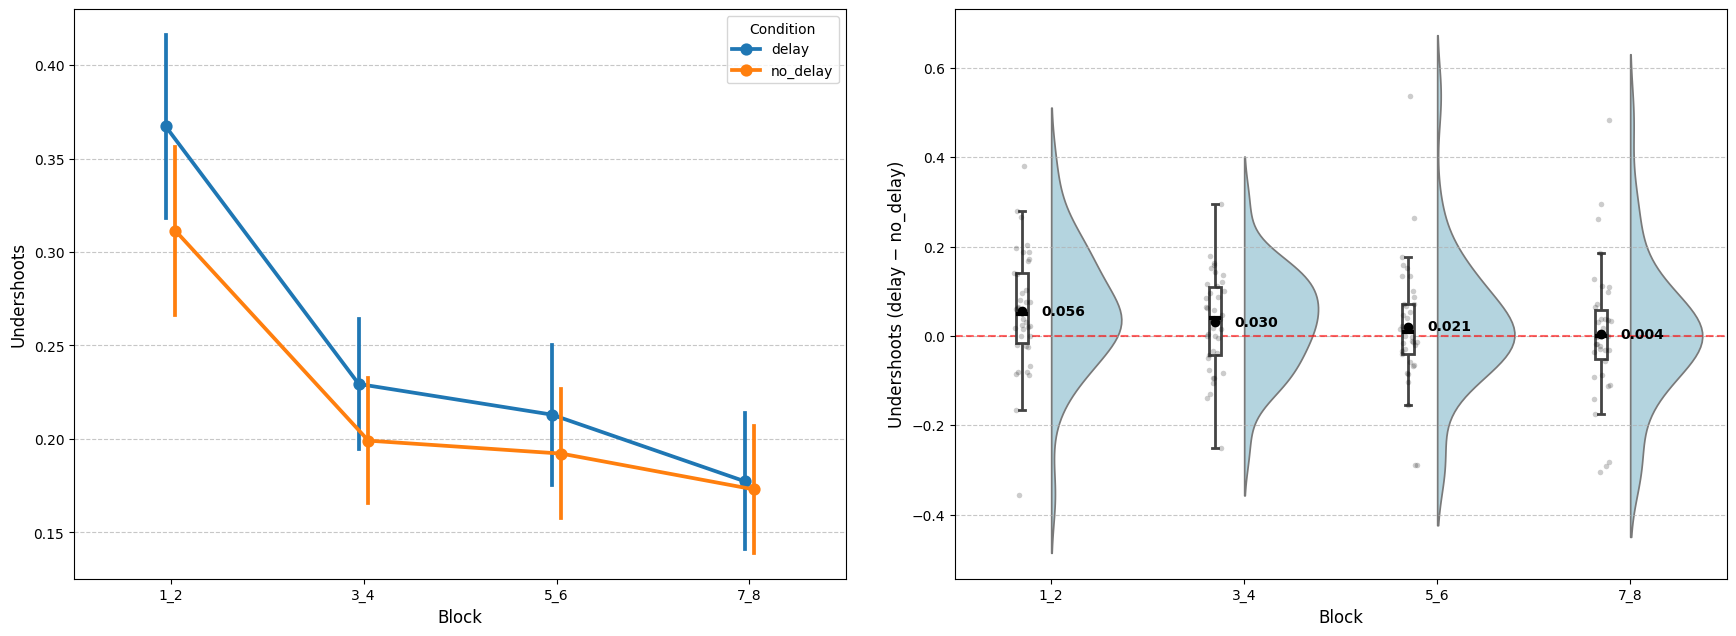

In [57]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_undershoots, 
    y_col="undershoots", 
    ylabel_left="Undershoots", 
    ylabel_right="Undershoots (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=3
)

In [58]:
aov = pg.rm_anova(
    dv="undershoots",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source        SS  ddof1  ddof2        MS          F  \
0         condition  0.058861      1     37  0.058861   3.288416   
1              pair  1.209766      3    111  0.403255  20.769135   
2  condition * pair  0.026312      3    111  0.008771   1.435117   

          p_unc     p_GG_corr       np2       eps  
0  7.788824e-02  7.788824e-02  0.081622  1.000000  
1  9.400447e-11  1.217075e-08  0.359520  0.754219  
2  2.364067e-01  2.385402e-01  0.037339  0.929762  


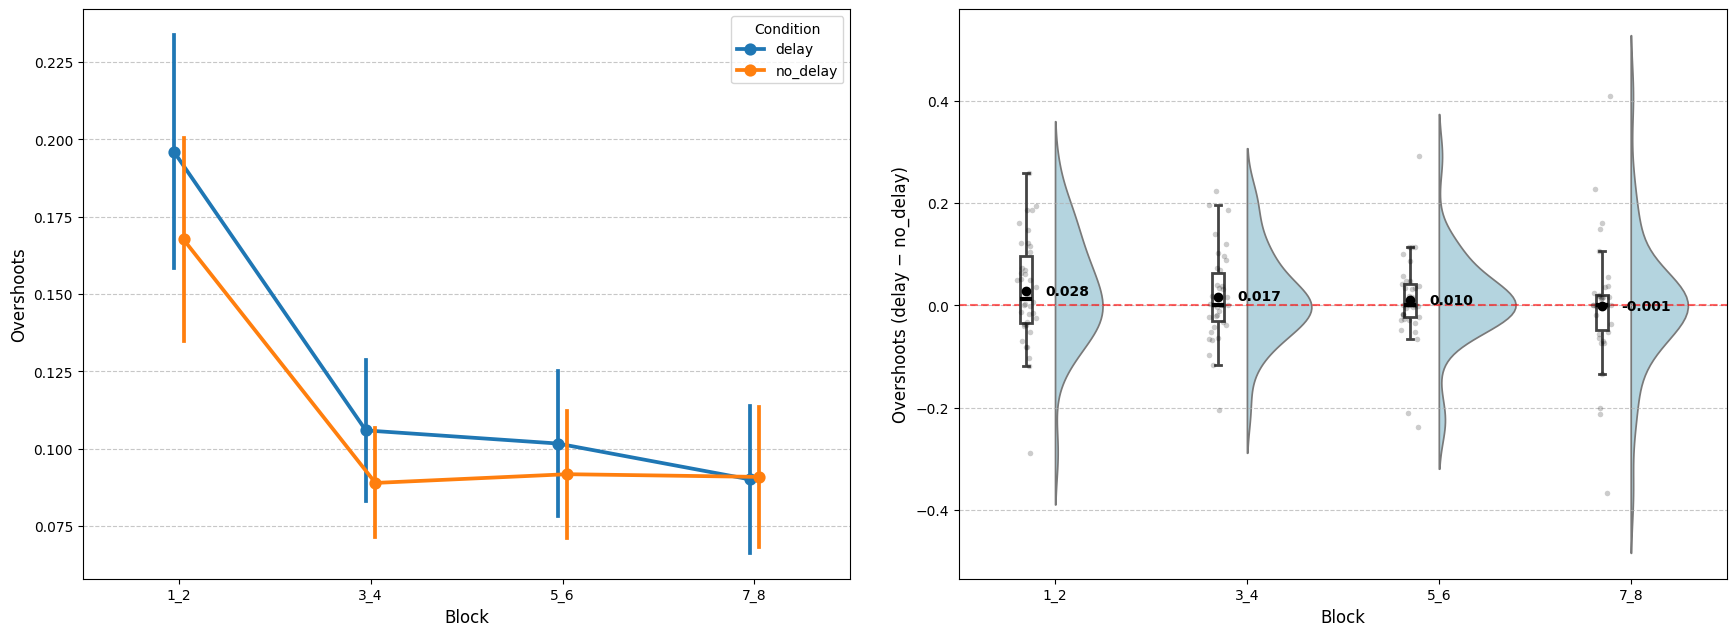

In [59]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_overshoots, 
    y_col="overshoots", 
    ylabel_left="Overshoots", 
    ylabel_right="Overshoots (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=3
)

In [60]:
aov = pg.rm_anova(
    dv="overshoots",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source        SS  ddof1  ddof2        MS          F     p_unc  \
0         condition  0.014102      1     37  0.014102   1.428518  0.239611   
1              pair  0.433304      3    111  0.144435  10.801116  0.000003   
2  condition * pair  0.008551      3    111  0.002850   0.812300  0.489676   

   p_GG_corr       np2       eps  
0   0.239611  0.037173  1.000000  
1   0.000022  0.225960  0.789684  
2   0.468567  0.021482  0.814565  


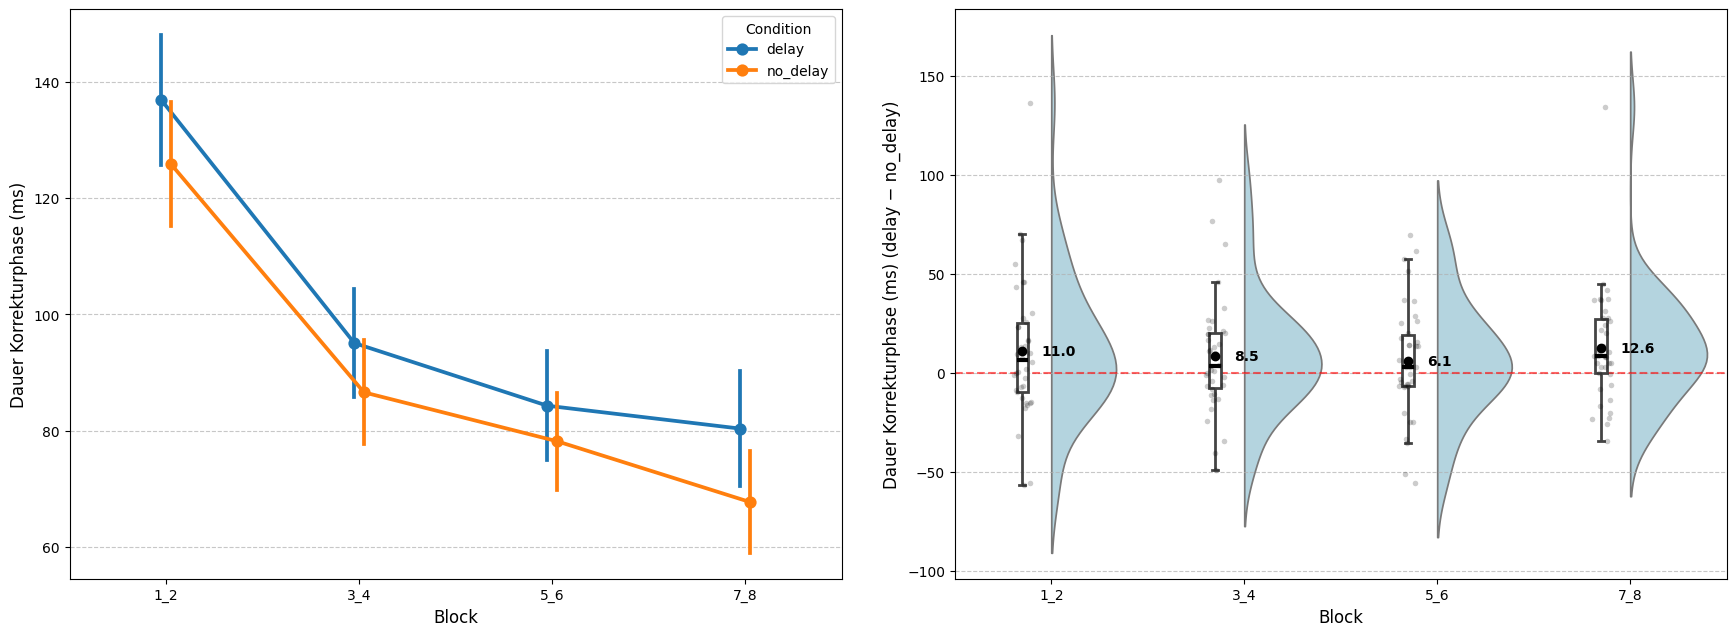

In [61]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_correction_duration, 
    y_col="correction_duration", 
    ylabel_left="Dauer Korrekturphase (ms)", 
    ylabel_right="Dauer Korrekturphase (ms) (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=1
)

In [62]:
aov = pg.rm_anova(
    dv="correction_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source             SS  ddof1  ddof2            MS          F  \
0         condition    6955.152201      1     37   6955.152201   6.770383   
1              pair  149730.293774      3    111  49910.097925  40.397969   
2  condition * pair     468.834965      3    111    156.278322   0.554239   

          p_unc     p_GG_corr       np2       eps  
0  1.325171e-02  1.325171e-02  0.154680  1.000000  
1  1.001191e-17  2.527032e-15  0.521951  0.844028  
2  6.463597e-01  6.211575e-01  0.014758  0.863913  


In [63]:
df_results_correction_duration = run_posthoc_analysis(df_diff_correction_duration, "correction_duration")


Post-hoc Ergebnisse für correction_duration:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t  p_adj     d
  1_2     125.889       65.367  136.924    68.735 11.035 1.925  0.109 0.312
  3_4      86.596       55.175   95.082    57.084  8.486 1.788  0.109 0.290
  5_6      78.183       51.327   84.294    58.123  6.111 1.324  0.193 0.215
  7_8      67.717       53.957   80.351    61.308 12.634 2.698  0.042 0.438


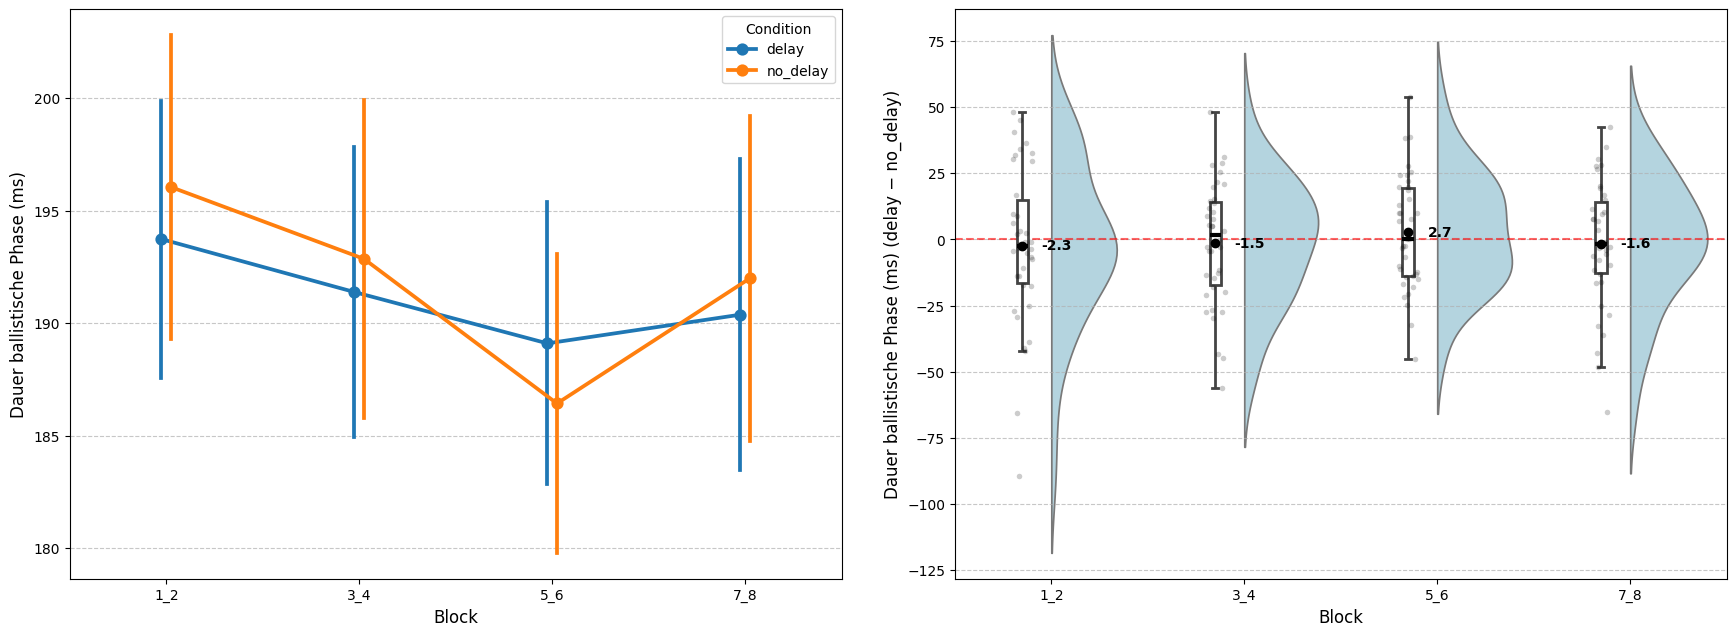

In [64]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_ballistic_duration, 
    y_col="ballistic_duration", 
    ylabel_left="Dauer ballistische Phase (ms)", 
    ylabel_right="Dauer ballistische Phase (ms) (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=1
)

In [65]:
aov = pg.rm_anova(
    dv="ballistic_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source           SS  ddof1  ddof2          MS         F  \
0         condition    35.425678      1     37   35.425678  0.040426   
1              pair  1969.515869      3    111  656.505290  1.372522   
2  condition * pair   292.544545      3    111   97.514848  0.808145   

      p_unc  p_GG_corr       np2       eps  
0  0.841751   0.841751  0.001091  1.000000  
1  0.254939   0.257863  0.035768  0.854608  
2  0.491947   0.470789  0.021375  0.816016  


In [66]:
df_results_ballistic_duration = run_posthoc_analysis(df_diff_ballistic_duration, "ballistic_duration")


Post-hoc Ergebnisse für ballistic_duration:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff      t  p_adj      d
  1_2     196.047       41.600  193.736    37.960 -2.311 -0.474  0.698 -0.077
  3_4     192.856       43.617  191.384    39.623 -1.472 -0.392  0.698 -0.064
  5_6     186.432       40.911  189.103    38.647  2.671  0.767  0.698  0.124
  7_8     191.997       44.563  190.378    42.565 -1.619 -0.416  0.698 -0.068


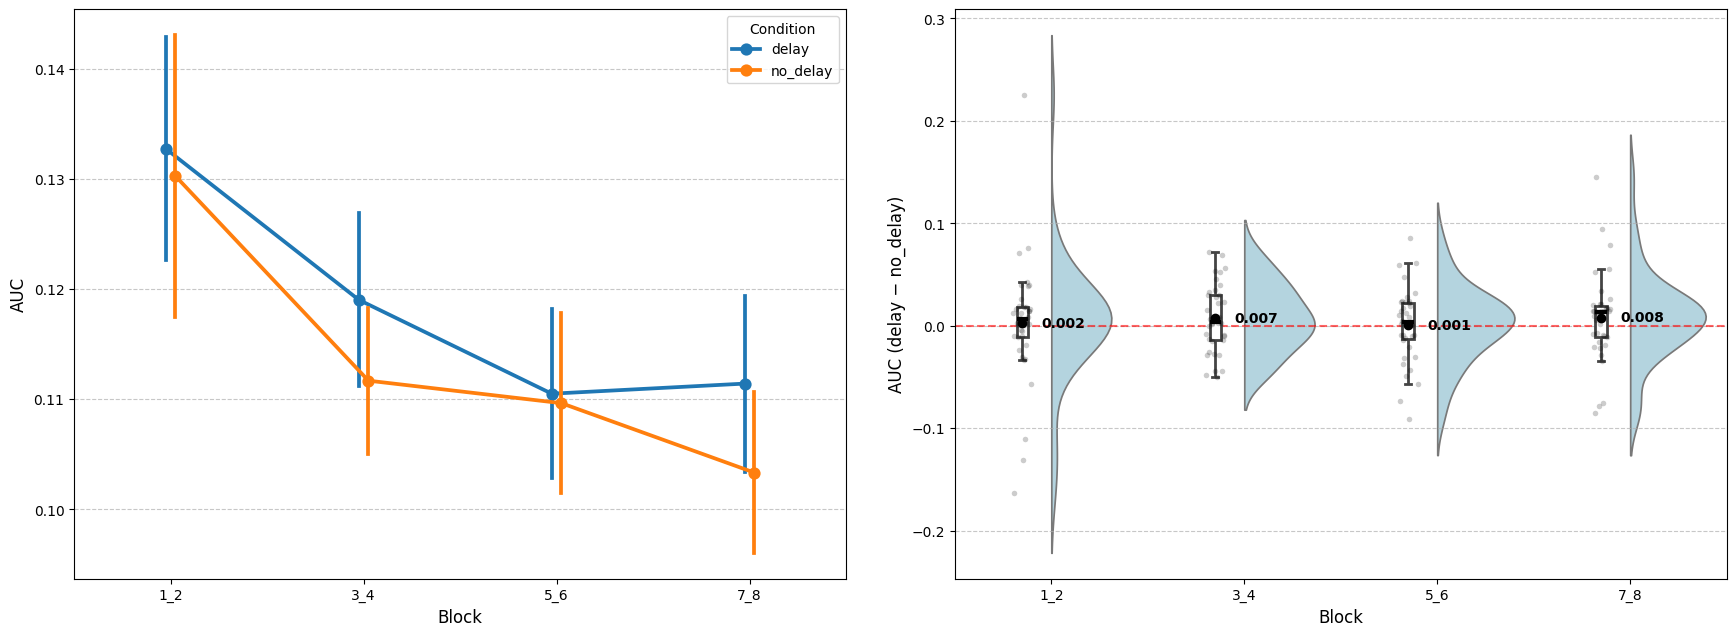

In [67]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_auc, 
    y_col="auc", 
    ylabel_left="AUC", 
    ylabel_right="AUC (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=3
)

In [68]:
aov = pg.rm_anova(
    dv="auc",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source        SS  ddof1  ddof2        MS         F     p_unc  \
0         condition  0.001673      1     37  0.001673  1.249127  0.270924   
1              pair  0.026634      3    111  0.008878  6.871619  0.000274   
2  condition * pair  0.000725      3    111  0.000242  0.280483  0.839389   

   p_GG_corr       np2       eps  
0   0.270924  0.032658  1.000000  
1   0.001679  0.156630  0.681762  
2   0.762136  0.007524  0.685149  


In [69]:
df_diff_max_correction_speed = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='max_correction_speed'
).reset_index()
df_diff_max_correction_speed['diff'] = df_diff_max_correction_speed['delay'] - df_diff_max_correction_speed['no_delay']

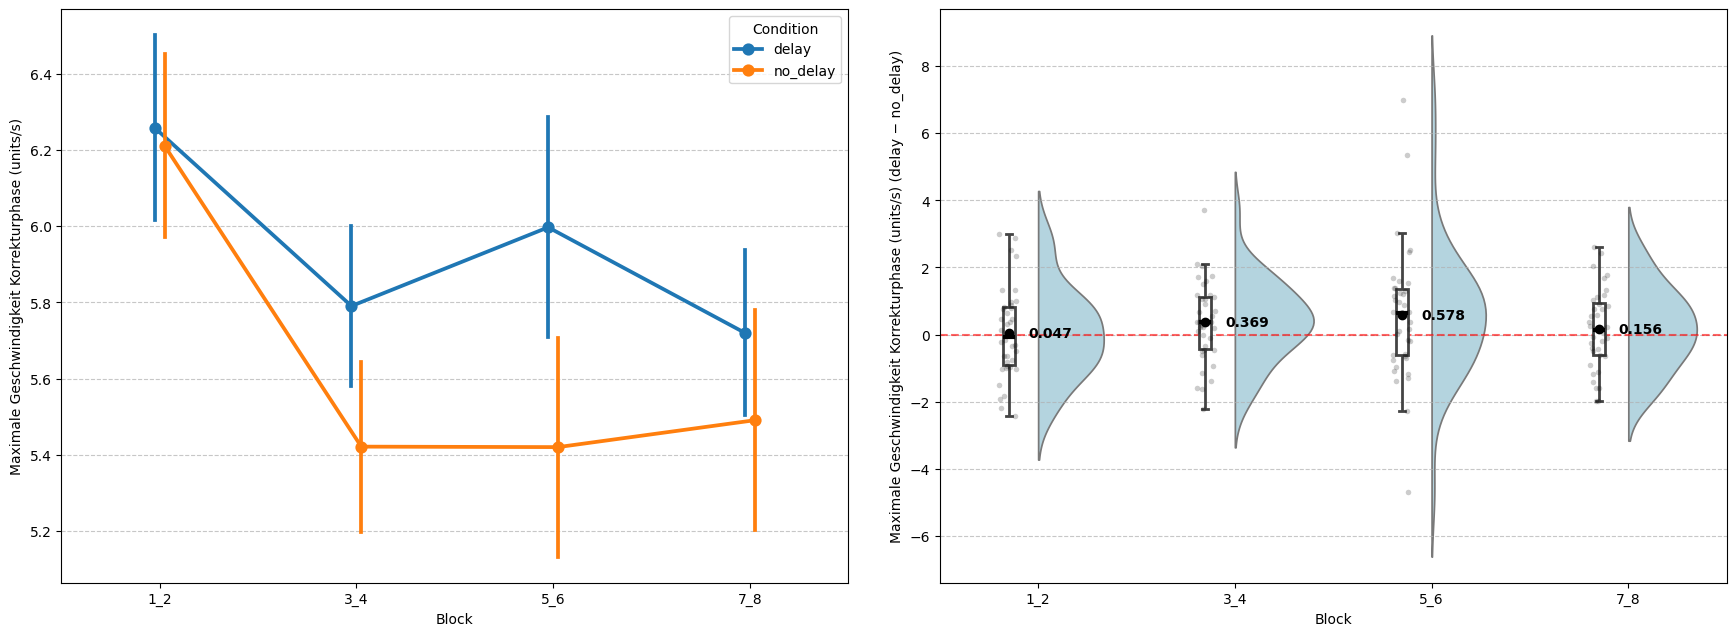

In [70]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_max_correction_speed, 
    y_col="max_correction_speed", 
    ylabel_left="Maximale Geschwindigkeit Korrekturphase (units/s)", 
    ylabel_right="Maximale Geschwindigkeit Korrekturphase (units/s) (delay − no_delay)",
    pair_order=None,
    base_size=10,
    decimals=3
)

In [72]:
aov = pg.rm_anova(
    dv="max_correction_speed",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source         SS  ddof1  ddof2        MS          F  \
0         condition   5.584465      1     35  5.584465   2.967746   
1              pair  27.780496      3    105  9.260165  14.571440   
2  condition * pair   2.759227      3    105  0.919742   1.923954   

          p_unc     p_GG_corr       np2       eps  
0  9.376663e-02  9.376663e-02  0.078165  1.000000  
1  5.285829e-08  5.873306e-07  0.293948  0.824073  
2  1.301998e-01  1.357550e-01  0.052106  0.917876  


In [73]:
df_diff_avg_correction_speed = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='avg_correction_speed'
).reset_index()
df_diff_avg_correction_speed['diff'] = df_diff_avg_correction_speed['delay'] - df_diff_avg_correction_speed['no_delay']

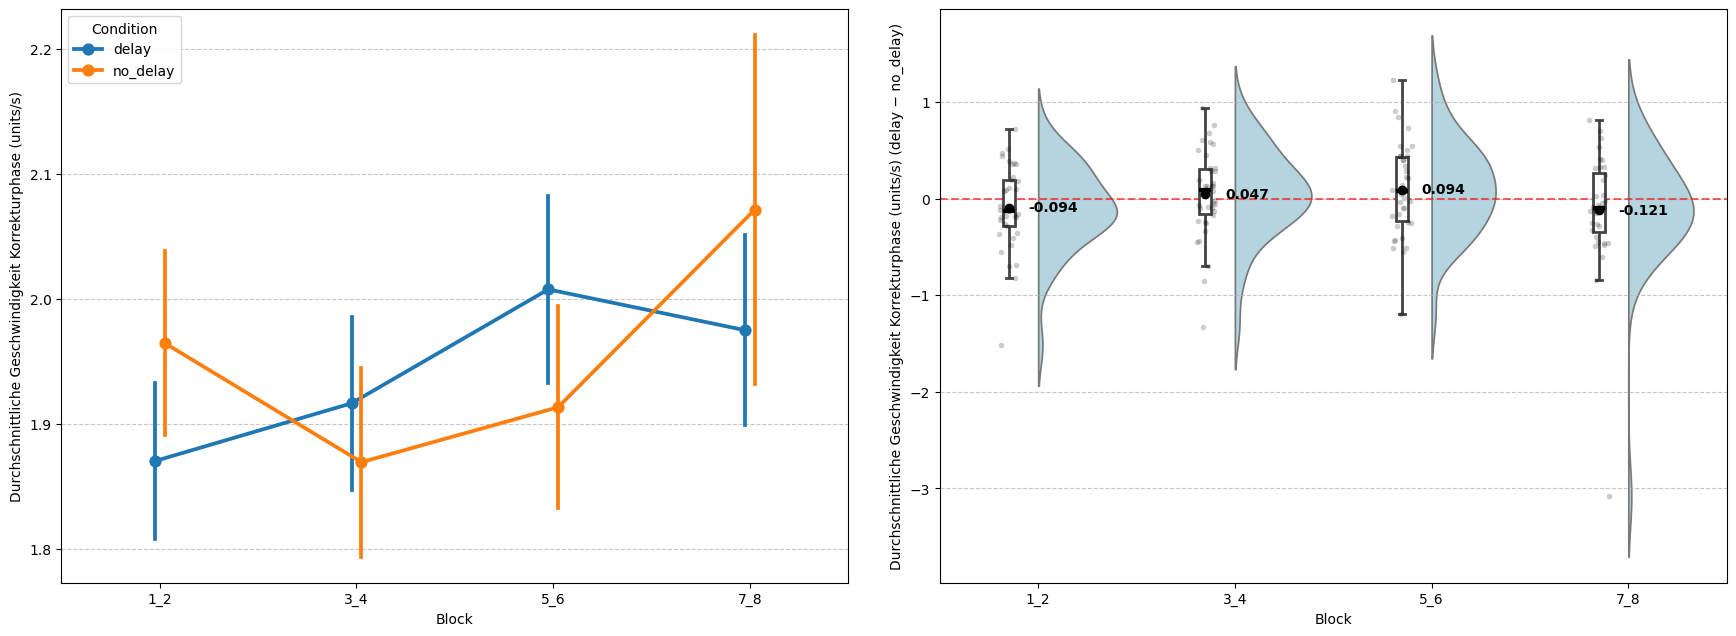

In [74]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_avg_correction_speed, 
    y_col="avg_correction_speed", 
    ylabel_left="Durchschnittliche Geschwindigkeit Korrekturphase (units/s)", 
    ylabel_right="Durchschnittliche Geschwindigkeit Korrekturphase (units/s) (delay − no_delay)",
    pair_order=None,
    base_size=10,
    decimals=3
)

In [76]:
aov = pg.rm_anova(
    dv="avg_correction_speed",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source        SS  ddof1  ddof2        MS         F     p_unc  \
0         condition  0.008119      1     35  0.008119  0.044337  0.834448   
1              pair  0.862902      3    105  0.287634  1.929451  0.129318   
2  condition * pair  0.578751      3    105  0.192917  2.089182  0.106085   

   p_GG_corr       np2       eps  
0   0.834448  0.001265  1.000000  
1   0.162030  0.052247  0.539065  
2   0.120153  0.056329  0.808039  
